In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#60D3FF", "#8ADD67", "#F6CC58", "#FF85CA", "#C580D6"]
sns.set_palette(colors)

sns.color_palette()

[(0.3764705882352941, 0.8274509803921568, 1.0),
 (0.5411764705882353, 0.8666666666666667, 0.403921568627451),
 (0.9647058823529412, 0.8, 0.34509803921568627),
 (1.0, 0.5215686274509804, 0.792156862745098),
 (0.7725490196078432, 0.5019607843137255, 0.8392156862745098)]

## Data

In [22]:
from itertools import product
from pandas import concat, read_csv

# from pandas import DataFrame, concat

# models = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT"]
# methods = ["Base", "Manual", "Reversify", "Checkpoint"]
# latency = [0.014868, 0.02773, 0.015056, 0.034049, 0.0471814, 0.0892162, 0.1762752, 0.06356714, 0.068613, 0.120468, 0.2610607, 0.0896976, 0.043146, 0.074249, 0.1580897, 0.059197, 0.137831, 0.850464, 0.16305462, 0.15804596, 0.263261, 0.302247, 0.293094, 0.293094, 0.24688, 0, 0.321261, 0.313457, 0.23519, 0.24336, 0.251446, 0.273538, 0.238013, 0, 0.25778, 0.263786]
# memory = [1552, 1500, 1470, 1500, 1850, 1510, 2164, 1850, 2918, 1964, 2152, 2912, 2112, 2392, 2470, 2092, 3242, 3680, 2220, 2864, 1714, 1694, 1648, 1916, 7120, 0, 2700, 2808, 2102, 1916, 1860, 1916, 2270, 0, 2156, 2158]
# cpu_time = [35.949, 76.855, 35.93, 99.575, 111.048, 251.122, 500.258, 186.473, 165.155, 340.794, 739.043, 262.809, 101.31, 79.544, 446.758, 173.734, 79.252, 3421, 173.571, 185.571, 93.166, 169.99, 148.176, 185.645, 520.503, 0, 763.96, 767.088, 34.881, 64.94, 69.528, 81.754, 63.445, 0, 135.727, 115.115]
# gpu_time = [18.64, 34.582, 18.674, 41.028, 62.956, 98.516, 147.204, 79.992, 102.952, 200.492, 217.904, 132.378, 52.186, 156.026, 83.776, 68, 148.176, 2892, 186.834, 156.834, 34.272, 45.534, 79.252, 116.39, 1076, 0, 1527, 1526, 20.068, 58.456, 50.718, 71.888, 66.836, 0, 86.48, 85.612]

# table_models = [m for m in models for _ in range(len(methods))]
# table_methods = methods * len(models)

# data = DataFrame(dict(
#     model=table_models, 
#     method=table_methods, 
#     latency=latency, 
#     memory=memory, 
#     cpu_time=cpu_time, 
#     gpu_time=gpu_time
# ))

# data.to_csv("data.csv", index=False)

data = read_csv("data.csv")
data.loc[data.method == "Base", "method"] = "Original"
data.loc[data.method == "Manual", "method"] = "SOTA-Revs"
data.loc[data.method == "Reversify", "method"] = "ReverSyn"

data

,model,method,latency,memory,cpu_time,gpu_time
0,ResNet32,Original,0.014868,1552,35.949,18.640
1,ResNet32,SOTA-Revs,0.027730,1500,76.855,34.582
2,ResNet32,ReverSyn,0.015056,1470,35.930,18.674
3,ResNet32,Checkpoint,0.034049,1500,99.575,41.028
4,ResNet110,Original,0.047181,1850,111.048,62.956
5,ResNet110,SOTA-Revs,0.089216,1510,251.122,98.516
6,ResNet110,ReverSyn,0.176275,2164,500.258,147.204
7,ResNet110,Checkpoint,0.063567,1850,186.473,79.992
8,ResNet164,Original,0.068613,2918,165.155,102.952
9,ResNet164,SOTA-Revs,0.120468,1964,340.794,200.492


## Memory

In [23]:
resnet = data[data.model == "ResNet32"]
others = data[~data.model.str.contains("ResNet")]
data_filtered = concat([resnet, others])

data_filtered

,model,method,latency,memory,cpu_time,gpu_time
0,ResNet32,Original,0.014868,1552,35.949,18.640
1,ResNet32,SOTA-Revs,0.027730,1500,76.855,34.582
2,ResNet32,ReverSyn,0.015056,1470,35.930,18.674
3,ResNet32,Checkpoint,0.034049,1500,99.575,41.028
16,GPT,Original,0.137831,3242,79.252,148.176
17,GPT,SOTA-Revs,0.850464,3680,3421.000,2892.000
18,GPT,ReverSyn,0.163055,2220,173.571,186.834
19,GPT,Checkpoint,0.158046,2864,185.571,156.834
20,Swin,Original,0.263261,1714,93.166,34.272
21,Swin,SOTA-Revs,0.302247,1694,169.990,45.534


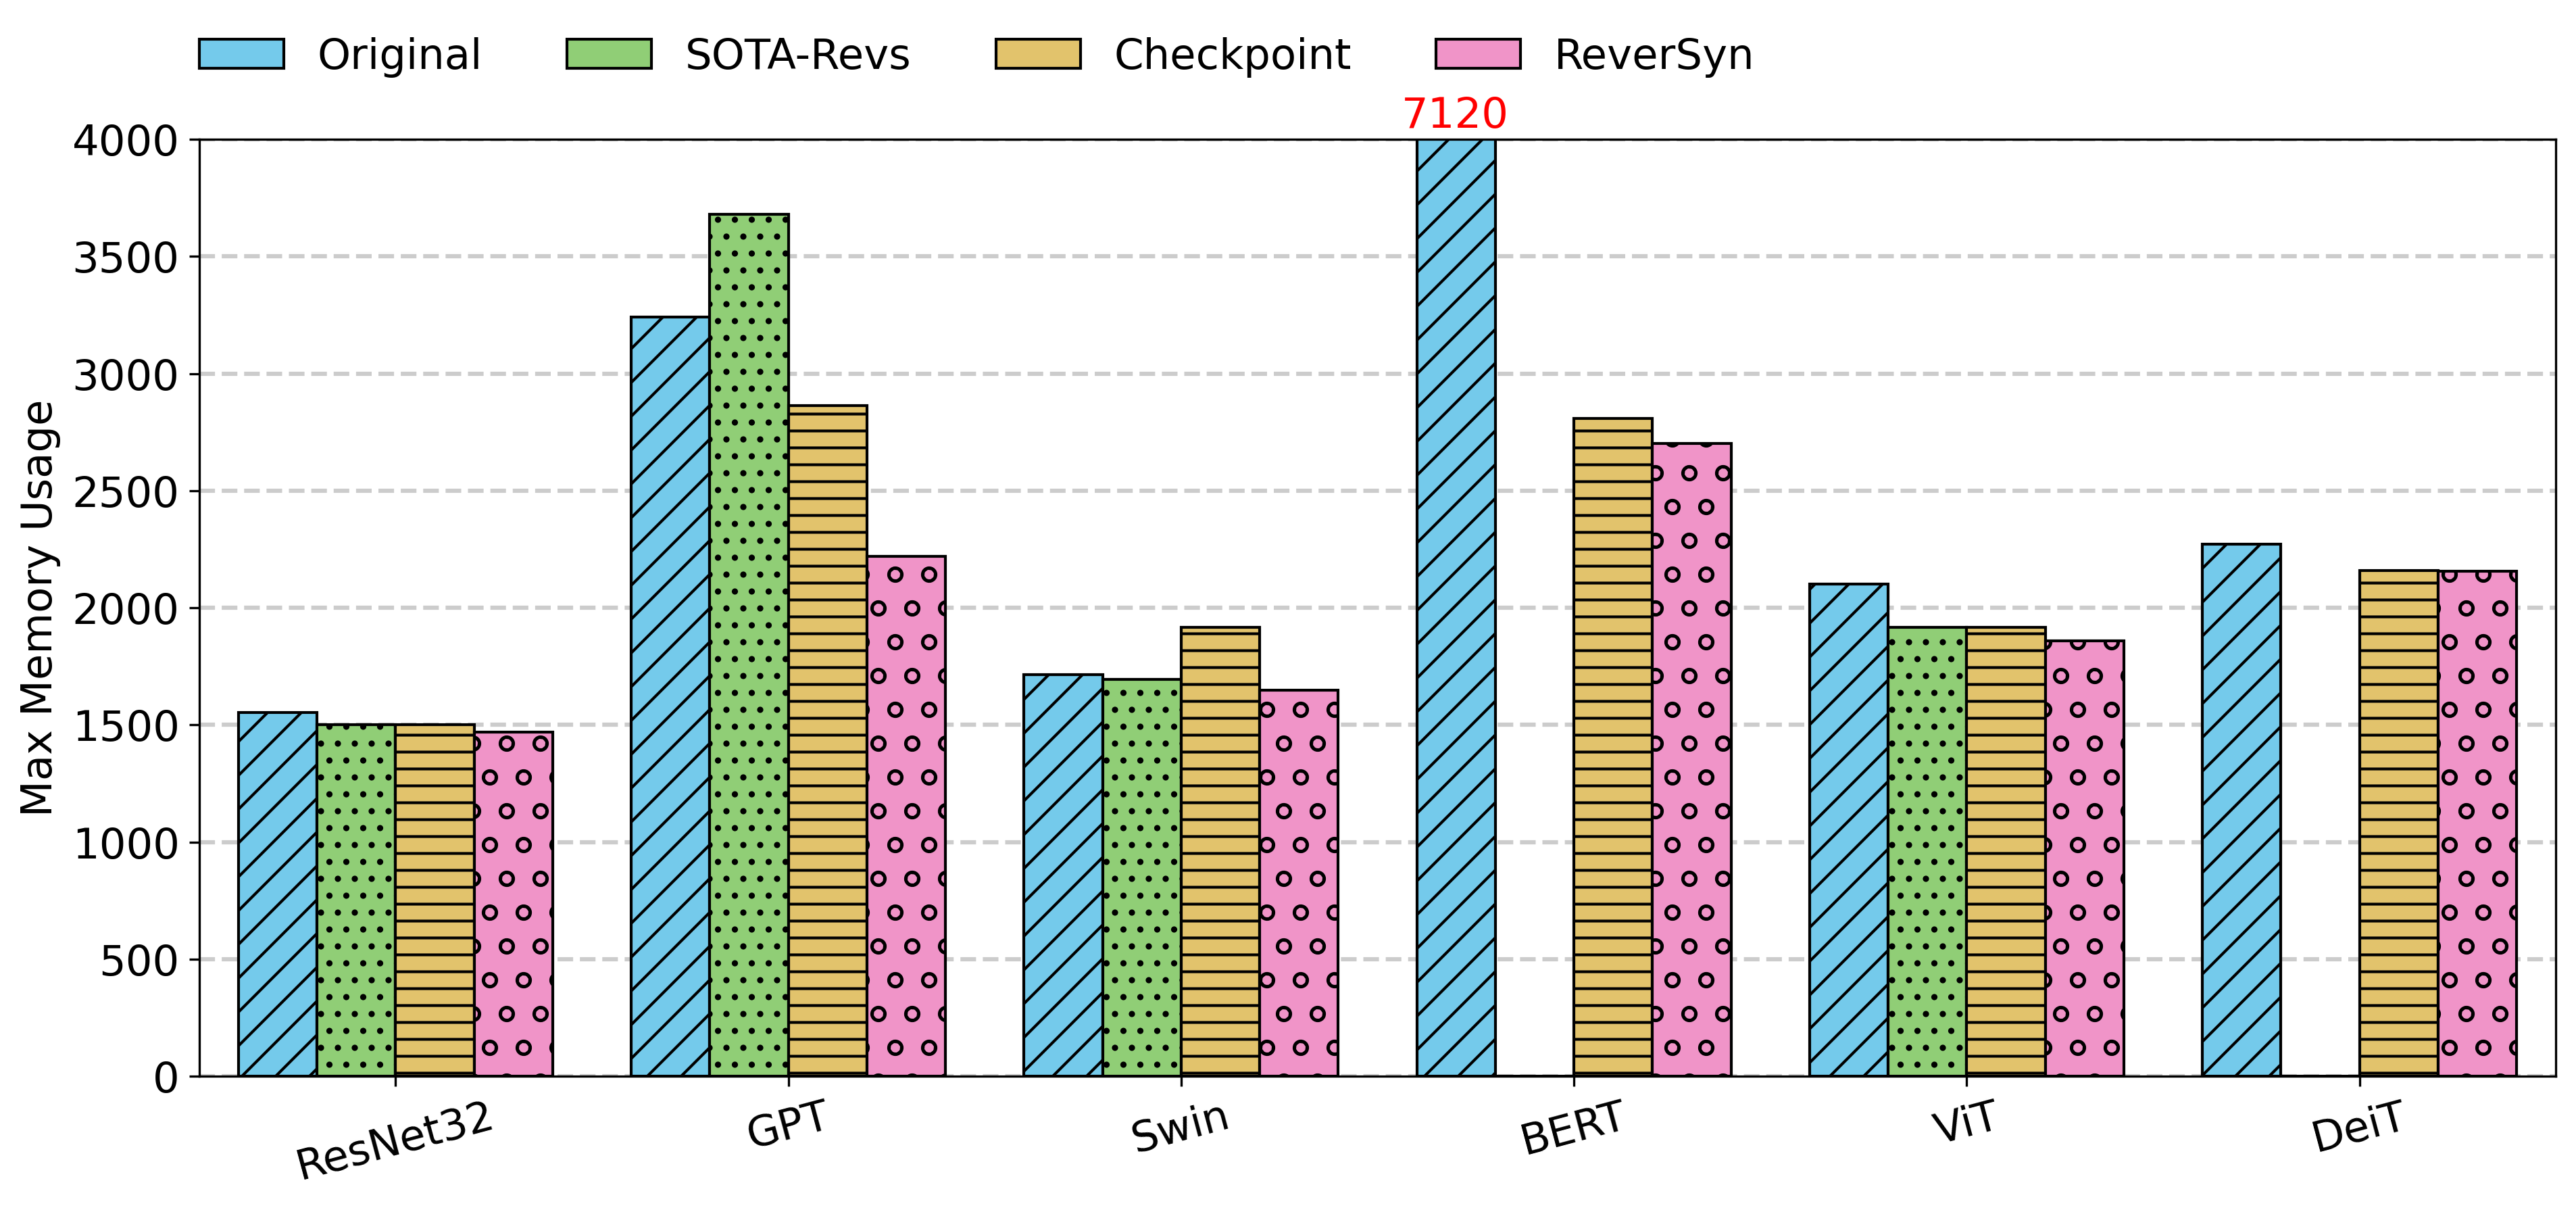

In [56]:
fontsize = 15
hatches = ["//", "..", "--", "o"]

plt.rcParams["figure.figsize"] = (15, 6)

ax = sns.barplot(data_filtered, x="model", y="memory", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black")

plt.xlabel(None)
plt.ylabel("Max Memory Usage", fontsize=fontsize)
plt.legend(loc="upper center", bbox_to_anchor=(0.33, 1.15), ncols=4, frameon=False, fontsize=fontsize)

plt.xticks(rotation=15)
plt.ylim(0, 4000)

plt.tick_params(axis="x", labelsize=fontsize)
plt.tick_params(axis="y", labelsize=fontsize)

for tick in ax.get_yticks():
    ax.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(set(data_filtered.model))])
    
# 特殊处理 bert base
bert_base_bar = ax.patches[3]
plt.text(bert_base_bar.get_x() - 0.04, 4050, int(data[(data.model == "BERT") & (data.method == "Original")].memory), color="red", fontsize=fontsize)

plt.savefig("memory.png", bbox_inches="tight", dpi=300, pad_inches=0.1)

## Latency

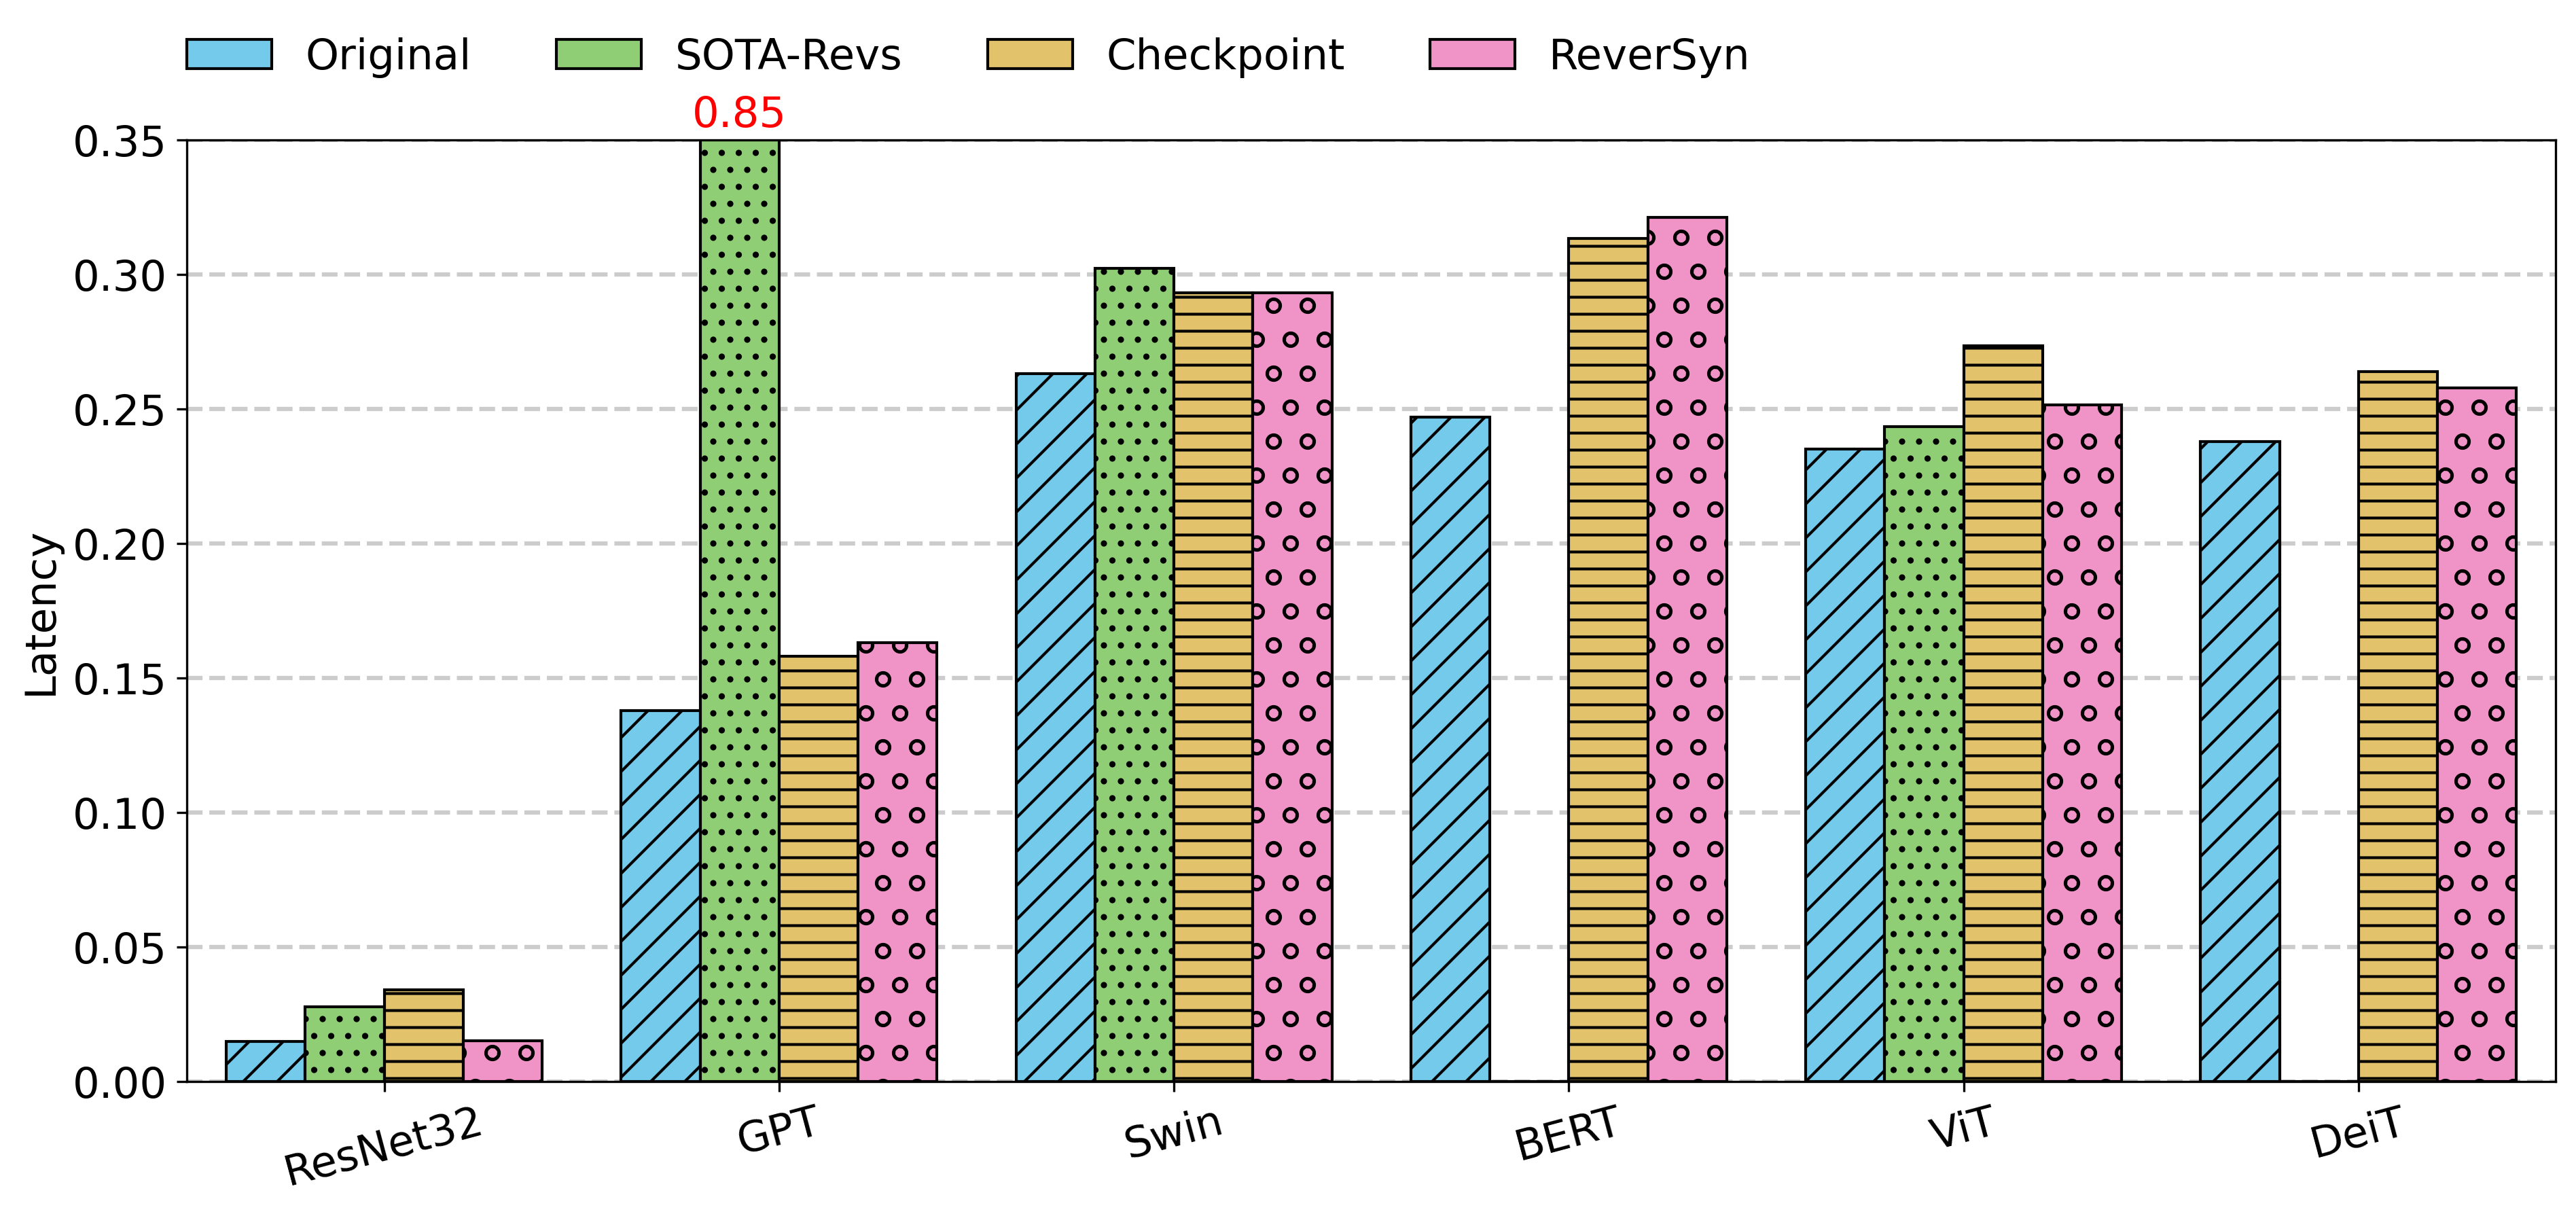

In [57]:
plt.rcParams["figure.figsize"] = (15, 6)

ax = sns.barplot(data_filtered, x="model", y="latency", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black")

plt.xlabel(None)
plt.ylabel("Latency", fontsize=fontsize)
plt.legend(loc="upper center", bbox_to_anchor=(0.33, 1.15), ncols=4, frameon=False, fontsize=fontsize)

plt.xticks(rotation=15)
plt.ylim(0, 0.35)

plt.tick_params(axis="x", labelsize=fontsize)
plt.tick_params(axis="y", labelsize=fontsize)

for tick in ax.get_yticks():
    ax.axhline(y=tick, color="gray", linestyle="--", zorder=0, alpha=0.4)
    
for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(set(data_filtered.model))])    
    
# 特殊处理 gpt manual
gpt_manual_bar = ax.patches[7]
plt.text(gpt_manual_bar.get_x() - 0.02, 0.355, round(float(data[(data.model == 'GPT') & (data.method == 'SOTA-Revs')].latency), 2), color="red", fontsize=fontsize)

plt.savefig("latency.png", bbox_inches="tight", dpi=300, pad_inches=0.1)